## PRISMA Hyperspectral Cube Visualization

Load a PRISMA scene and render it as a 3D hypercube showing spatial (H, W) and spectral (C) dimensions.

### 1. Load PRISMA scene

In [1]:
import os
import sys
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Affine2D
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

PROJECT_ROOT = str(pathlib.Path(os.getcwd()).parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from app.models.file_processing.sources import FileSourceConfig
from app.utils.dataset_builder.prisma_dataset_builder import PrismaDatasetBuilder

PRISMA_HE5 = os.path.join(
    PROJECT_ROOT,
    "tests/test_payloads/prisma_1/PRS_L2D_STD_20260104051849_20260104051854_0001.he5",
)

builder = PrismaDatasetBuilder(
    file_source_configuration=FileSourceConfig(source_path=PRISMA_HE5)
)
vendable = builder.vend_dataset()

cube = vendable.normalized_hyperspectral_cube    # (C, H, W)
validity = vendable.validity_cube                # (C, H, W)
wavelengths = vendable.band_cw_order             # center wavelengths per band

print(f"Cube shape (C, H, W): {cube.shape}")
print(f"Validity shape: {validity.shape}")
print(f"Wavelength range: {min(wavelengths):.1f} – {max(wavelengths):.1f} nm")
print(f"Value range: [{np.nanmin(cube):.4f}, {np.nanmax(cube):.4f}]")

Using device: mps
Using device: mps
Cube shape (C, H, W): (239, 1199, 1248)
Validity shape: (239, 1199, 1248)
Wavelength range: 0.0 – 2497.1 nm
Value range: [0.0000, 1.0000]


### 2. Render 3D hypercube

Draws three visible faces of the cube:
- **Top**: RGB composite (spatial view)
- **Front**: spectral cross-section along a row (bands × width)
- **Side**: spectral cross-section along a column (bands × height)

In [2]:
def make_rgb(cube, wavelengths, validity):
    """Pick bands closest to R=650nm, G=550nm, B=450nm and build an RGB image."""
    wl = np.array(wavelengths)
    rgb_targets = [650, 550, 450]  # nm
    band_indices = [int(np.argmin(np.abs(wl - t))) for t in rgb_targets]

    rgb = np.stack([cube[b] for b in band_indices], axis=-1)  # (H, W, 3)
    mask = validity[band_indices[0]]  # use red band validity

    # Mask invalid pixels
    rgb[mask == 0] = 0

    # Percentile stretch for display (2nd–98th over valid pixels)
    for ch in range(3):
        valid_vals = rgb[:, :, ch][mask == 1]
        if len(valid_vals) == 0:
            continue
        lo, hi = np.percentile(valid_vals, [2, 98])
        rgb[:, :, ch] = np.clip((rgb[:, :, ch] - lo) / (hi - lo + 1e-10), 0, 1)

    return rgb, band_indices


def make_spectral_slice(cube, validity, axis, index):
    """Extract a spectral cross-section.

    axis=1 (row slice) -> shape (C, W) — front face
    axis=2 (col slice) -> shape (C, H) — side face
    """
    if axis == 1:
        slc = cube[:, index, :]          # (C, W)
        val = validity[:, index, :]
    else:
        slc = cube[:, :, index]          # (C, H)
        val = validity[:, :, index]

    slc = slc.copy()
    slc[val == 0] = 0

    # Normalize for display
    valid_vals = slc[val == 1]
    if len(valid_vals) > 0:
        lo, hi = np.percentile(valid_vals, [2, 98])
        slc = np.clip((slc - lo) / (hi - lo + 1e-10), 0, 1)

    return slc


rgb_top, rgb_bands = make_rgb(cube, wavelengths, validity)
C, H, W = cube.shape

# Pick slices near the middle
front_slice = make_spectral_slice(cube, validity, axis=1, index=H // 2)  # (C, W)
side_slice = make_spectral_slice(cube, validity, axis=2, index=W // 2)   # (C, H)

print(f"RGB bands: {[wavelengths[b] for b in rgb_bands]} nm (indices {rgb_bands})")
print(f"Front slice shape (C, W): {front_slice.shape}")
print(f"Side slice shape (C, H): {side_slice.shape}")

RGB bands: [645.9638061523438, 550.9146118164062, 453.38946533203125] nm (indices [208, 219, 232])
Front slice shape (C, W): (239, 1248)
Side slice shape (C, H): (239, 1199)


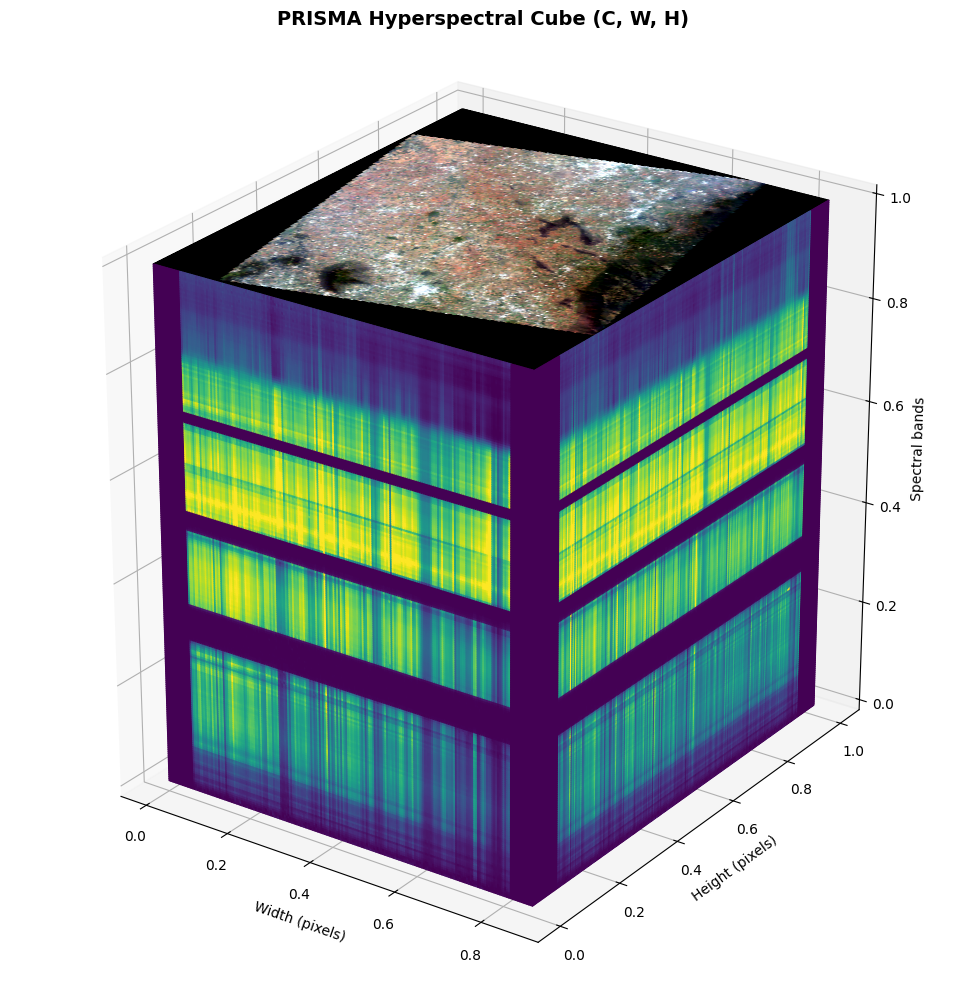

In [3]:
def render_hypercube(rgb_top, front_slice, side_slice, wavelengths, figsize=(12, 10)):
    """Render a 3D-looking hypercube using matplotlib's 3D axes.

    - Top face: RGB composite (spatial)
    - Front face: spectral slice along a row (bands vs width)
    - Right face: spectral slice along a column (bands vs height)
    """
    C_bands, W_img = front_slice.shape
    _, H_img = side_slice.shape
    H_top, W_top = rgb_top.shape[:2]

    # Downsample for rendering performance
    max_dim = 200
    step_h = max(1, H_top // max_dim)
    step_w = max(1, W_top // max_dim)
    step_c = max(1, C_bands // max_dim)

    rgb_ds = rgb_top[::step_h, ::step_w]
    front_ds = front_slice[::step_c, ::step_w]
    side_ds = side_slice[::step_c, ::step_h]

    h, w = rgb_ds.shape[:2]
    c_f, w_f = front_ds.shape
    c_s, h_s = side_ds.shape

    # Normalize cube dimensions for display
    scale = 1.0 / max(h, w, c_f)
    sx, sy, sz = w * scale, h * scale, c_f * scale

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    # --- Top face: RGB at z = sz ---
    xx_top = np.linspace(0, sx, w)
    yy_top = np.linspace(0, sy, h)
    X_top, Y_top = np.meshgrid(xx_top, yy_top)
    Z_top = np.full_like(X_top, sz)

    ax.plot_surface(
        X_top, Y_top, Z_top,
        facecolors=rgb_ds,
        shade=False,
        rstride=1, cstride=1,
    )

    # --- Front face: spectral slice at y = 0 ---
    xx_front = np.linspace(0, sx, w_f)
    zz_front = np.linspace(0, sz, c_f)
    X_front, Z_front = np.meshgrid(xx_front, zz_front)
    Y_front = np.zeros_like(X_front)

    # Convert grayscale to RGB for facecolors
    front_rgb = plt.cm.viridis(front_ds)[:, :, :3]

    ax.plot_surface(
        X_front, Y_front, Z_front,
        facecolors=front_rgb,
        shade=False,
        rstride=1, cstride=1,
    )

    # --- Right face: spectral slice at x = sx ---
    yy_side = np.linspace(0, sy, h_s)
    zz_side = np.linspace(0, sz, c_s)
    Y_side, Z_side = np.meshgrid(yy_side, zz_side)
    X_side = np.full_like(Y_side, sx)

    side_rgb = plt.cm.viridis(side_ds)[:, :, :3]

    ax.plot_surface(
        X_side, Y_side, Z_side,
        facecolors=side_rgb,
        shade=False,
        rstride=1, cstride=1,
    )

    # --- Styling ---
    ax.set_xlabel("Width (pixels)")
    ax.set_ylabel("Height (pixels)")
    ax.set_zlabel("Spectral bands")
    ax.set_title("PRISMA Hyperspectral Cube (C, W, H)", fontsize=14, fontweight="bold")

    # Good viewing angle
    ax.view_init(elev=25, azim=-55)
    ax.set_box_aspect([sx, sy, sz])

    plt.tight_layout()
    plt.show()


render_hypercube(rgb_top, front_slice, side_slice, wavelengths)